<a href="https://colab.research.google.com/github/weagan/Diffusion/blob/main/diffusion_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimalist High-Dimensional Diffusion Architecture Demo
This notebook implements a Denoising Diffusion Probabilistic Model (DDPM) matching our tensor matrix equations. It supports **0 (CPU), 1, or 2+ GPUs** dynamically and reads environment secrets securely in both Google Colab and Kaggle.

Diffusion architecture consists of two probabilistic processes—forward diffusion (adding noise to data) and reverse diffusion (iteratively denoising matrices)—that are modeled using stochastic tensor mathematics. The model acts as an estimator, training a neural network (often a U-Net or Transformer) to predict and subtract the noise from multidimensional data tensors. [1, 2, 3, 4, 5]
Here are the exact mathematical equations governing diffusion architectures, defined across high-dimensional tensors.
## 1. The Forward Diffusion Process (Adding Noise)
The forward process takes a clean data tensor $x_0$ and gradually corrupts it over $T$ steps into an isotropic Gaussian distribution. At any given step $t$, the distribution of the noisy tensor $x_t$ depends only on the previous step $x_{t-1}$: [2, 3, 6, 7, 8]
$q(x_t \vert{} x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I)$
Where:

* $\beta_t \in (0, 1)$ is the noise schedule (the variance of the noise added at step $t$).
* $I$ is the identity matrix matching the dimensionality of the tensor.
* $\mathcal{N}$ represents a normal distribution.

To compute the tensor $x_t$ directly at any arbitrary step $t$ without iterating, we use the reparameterization trick. We define $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{i=1}^{t} \alpha_i$:
$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$
Where $\epsilon \sim \mathcal{N}(0, I)$ is the random noise tensor injected at step $t$.
## 2. The Reverse Diffusion Process (Denoising)
The reverse process serves as the core generative mechanism. Because adding noise destroys data, we must train a neural network (parameterized by $\theta$) to predict and remove the noise from the noisy tensor $x_t$. The reverse transition step is also defined as a Gaussian distribution: [3, 9, 10, 11]
$p_\theta(x_{t-1} \vert{} x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$
The neural network aims to compute the mean $\mu_\theta$ by taking the noisy tensor $x_t$ and the noise variance embedding $t$, and attempting to estimate the exact noise tensor $\epsilon$. The formula to estimate the previous tensor state is: [4, 12, 13]
$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)$
Once $\mu_\theta$ is computed, the new tensor state $x_{t-1}$ is calculated by sampling:
$x_{t-1} = \mu_\theta(x_t, t) + \sqrt{\Sigma_\theta(x_t, t)} z, \quad z \sim \mathcal{N}(0, I)$ [14]
## 3. The Training Objective (Loss Function)
To train the network to accurately predict the noise at any arbitrary time step $t$, we optimize the neural network weights $\theta$. The objective is to minimize the Mean Squared Error (MSE) between the actual noise $\epsilon$ and the network's prediction $\epsilon_\theta(x_t, t)$ across the multidimensional tensor arrays: [4]
$L(\theta) = \mathbb{E}_{t, x_0, \epsilon} \left[ \Vert{} \epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, t) \Vert{}^2 \right]$
## 4. Tensor Mechanics in Network Layers
Under the hood, the $\epsilon_\theta$ function is a high-dimensional tensor transformation. For image-based models, this is processed through a U-Net; for modern Latent Diffusion Models (LDMs), this incorporates Transformer blocks. The transformation applies a sequence of tensor contractions (matmul) and non-linearities: [1, 15, 16, 17, 18]

   1. Sinusoidal Time Embedding: The scalar step $t$ is mapped to a vector to be integrated into the spatial tensors.
   2. Latent Mapping: The inputs (e.g., images) are compressed into lower-dimensional latent tensors.
   3. Multi-Head Attention (Transformer): The latent tensor $x_t$ is flattened and projected into Query, Key, and Value tensors (Matrices $Q$, $K$, $V$):
   $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$
   4. ResNet Blocks: Spatial convolutions and skip connections map the tensors back to the correct original shape to output the final predicted noise tensor $\epsilon_\theta$. [1, 4, 19, 20, 21]

If you are interested in applying this to a specific task, I can:

* Provide the Python (PyTorch) code for the forward and reverse math.
* Explain the difference between pixel-space and latent space (Latent Diffusion) models.
* Detail how text embeddings (CLIP) are integrated into the tensor math for conditional generation. [1]

Let me know which of these areas you would like to explore!

[1] [https://en.wikipedia.org](https://en.wikipedia.org/wiki/Diffusion_model)
[2] [https://www.youtube.com](https://www.youtube.com/watch?v=dSC9XOPJXK8)
[3] [https://nestdigital.com](https://nestdigital.com/blog/understanding-diffusion-stable-diffusion-in-ai/)
[4] [https://nathanbaileyw.medium.com](https://nathanbaileyw.medium.com/a-look-at-diffusion-models-79bd7e789964)
[5] [https://medium.com](https://medium.com/@watermellon2018/diffusion-models-in-computer-vision-what-are-they-7c2ca1facb20)
[6] [https://medium.com](https://medium.com/@kemalpiro/step-by-step-visual-introduction-to-diffusion-models-235942d2f15c)
[7] [https://pub.towardsai.net](https://pub.towardsai.net/physics-inspired-generative-modeling-diffusion-flow-matching-and-energy-based-models-9cbacb24488a)
[8] [https://openreview.net](https://openreview.net/pdf/93a74eb95d40b11486bb06cb0bf4f37bd28c9ba4.pdf)
[9] [https://epubs.siam.org](https://epubs.siam.org/doi/10.1137/23M1626232)
[10] [https://www.sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S1270963826009508)
[11] [https://colab.research.google.com](https://colab.research.google.com/github/galenwilkerson/Stable-Diffusion/blob/main/Stable_Diffusion_2.ipynb)
[12] [https://link.springer.com](https://link.springer.com/article/10.1007/s11063-025-11767-5)
[13] [https://www.sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S2214860424005244)
[14] [https://www.sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S2590197425000308)
[15] [https://towardsdatascience.com](https://towardsdatascience.com/diffusion-transformer-explained-e603c4770f7e/)
[16] [https://medium.com](https://medium.com/@xiaxiami/diffusion-model-explained-32296c8a6839)
[17] [https://ayushtues.medium.com](https://ayushtues.medium.com/rl-with-diffusion-i-d64c6e96d5ed)
[18] [https://ai.gopubby.com](https://ai.gopubby.com/a-closer-look-at-autoregressive-and-diffusion-based-language-models-c4bea36c6fa5)
[19] [https://medium.com](https://medium.com/@shubham.ksingh.cer14/diffusion-models-from-scratch-in-pytorch-cb6d349c14be)
[20] [https://samanemami.medium.com](https://samanemami.medium.com/a-comprehensive-guide-to-latent-space-9ae7f72bdb2f)
[21] [https://www.sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S0045782521005855)


This initial section sets up the necessary libraries and dynamically resolves environment secrets (like an API token) for both Google Colab and Kaggle environments. It also configures the computing device (CPU or GPU) based on availability.

In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# =========================================================================
# 0. ENVIRONMENT SECRETS RESOLVER (Colab & Kaggle Compatible)
# =========================================================================
SECRET_KEY_NAME = "HF_TOKEN"
api_token = os.environ.get(SECRET_KEY_NAME)

if not api_token:
    # Try Google Colab Secrets Engine
    try:
        from google.colab import userdata
        api_token = userdata.get(SECRET_KEY_NAME)
        print("Successfully fetched token from Google Colab Secrets.")
    except ImportError:
        # Try Kaggle Secrets Engine
        try:
            from kaggle_secrets import UserSecretsClient
            api_token = UserSecretsClient().get_secret(SECRET_KEY_NAME)
            print("Successfully fetched token from Kaggle Secrets.")
        except Exception:
            print(f"Warning: '{SECRET_KEY_NAME}' not found. Defaulting to mock/anonymous mode.")
            api_token = "ANONYMOUS_USER"

# =========================================================================
# 1. DYNAMIC COMPUTE HARNESS (0, 1, or 2+ GPUs)
# =========================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Executing pipeline on device: {device} | Total Available GPUs: {num_gpus}")

Successfully fetched token from Google Colab Secrets.
Executing pipeline on device: cpu | Total Available GPUs: 0


This markdown cell introduces the diffusion hyperparameter setup, which is crucial for defining how noise is added and removed during the diffusion process. It specifically mentions the linear noise schedule (beta), and derived alpha and alpha_bar terms.

### 2. The Diffusion Hyperparameter Setup
Here we construct the linear noise schedule $\beta_t$, and calculate the derived closed-form variance arrays $\alpha_t$ and $\bar{\alpha}_t$ across our discrete schedule timeline.

The `DiffusionPipeline` class defines the core logic of the DDPM. It initializes the noise schedule (`beta`, `alpha`, `alpha_bar`).

*   **`forward_diffusion`**: This method implements Equation 1, which adds noise to the original data (`x_0`) to produce a noisy version (`x_t`) at a given timestep `t`.
*   **`reverse_process`**: This method implements the sampling process. It starts with pure noise and iteratively denoises it using the trained neural network (`model`) to generate new samples. It uses the mean (`mu_theta`) and variance (`beta_t`) to guide this reverse transformation.

variance ($\Sigma_\theta$$\Sigma_\theta$) of the revers

 It seems counter-intuitive to _add_ noise during a _denoising_ process, but this is critical for the model's generative capabilities.

Recall that the reverse process is defined as a **stochastic (probabilistic) process**, specifically as a Gaussian distribution:

$$p_\theta(x_{t-1} \vert{} x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$$$p_\theta(x_{t-1} \vert{} x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

Your (the DiffusionEstimator) learns to predict the **mean** ($\mu_\theta$$\mu_\theta$) ofthis distribution. However, to actually _sample_ from this distribution to get x\_{t-1}, you don't just use the mean. You add a bit of new, random noise (scaled by torch.sqrt(beta\_t)).

Here's why this is done:

1.  **Stochasticity for Diversity**: If the reverse process were purely deterministic (only subtracting the predicted noise without adding new noise), it would generate the _exact same_ output every time for a given starting x\_t (pure noise). By adding this small, controlled amount of random noise at each step, the model can produce a wide variety of plausible samples, all consistent with the learned data distribution (the circle).
    
2.  **Matching the Forward Process**: The forward process _adds_ noise stochastically. To truly reverse this, the backward process must also be stochastic. The sqrt(beta\_t) \* noise term effectively acts as the variance ($\Sigma_\theta$$\Sigma_\theta$) of the reverse Gaussian distribution. It introduces the necessary randomness to explore the data manifold effectively.
    
3.  **Preventing Mode Collapse**: Without this stochasticity, the model might only learn to generate a very small subset of the data distribution, leading to a lack of diversity in generated samples (known as mode collapse).
    

So, while the main goal is to _denoise_ by moving towards the mean ($\mu_\theta$$\mu_\theta$) which is estimated by subtracting the predicted noise, the + torch.sqrt(beta\_t) \* noise term ensures that the step is probabilistic, allowing for rich and diverse sample generation.

In [2]:
class DiffusionPipeline:
    def __init__(self, timesteps=200, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.timesteps = timesteps
        self.device = device

        # Linear schedule configuration
        self.beta = torch.linspace(beta_start, beta_end, timesteps).to(device)

        # Equation 1 Derived Terms:
        # alpha_t = 1 - beta_t
        self.alpha = 1.0 - self.beta

        # bar{alpha}_t = prod_{i=1}^{t} alpha_i
        self.alpha_bar = torch.cumprod(self.alpha, dim=0).to(device)

    def forward_diffusion(self, x_0, t):
        r"""
        Equation 1: x_t = sqrt(bar{alpha}_t) x_0 + sqrt(1 - bar{alpha}_t) epsilon
        """
        epsilon = torch.randn_like(x_0).to(self.device)

        # Gather variables matching batch dimension shapes
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t]).view(-1, 1, 1)
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar[t]).view(-1, 1, 1)

        # Compute tensor transformation matrix
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * epsilon
        return x_t, epsilon

    @torch.no_grad()
    def reverse_process(self, model, num_samples=1000, shape=(2,), capture_steps=False, capture_interval=None):
        r"""
        Generate samples by reversing the diffusion process.
        Implements: x_{t-1} = (1/sqrt(alpha_t)) * (x_t - (1-alpha_t)/sqrt(1-bar{alpha}_t) * epsilon_theta(x_t, t)) + sqrt(beta_t) * z
        """
        model.eval()
        x_t = torch.randn(num_samples, 1, shape[0]).to(self.device) #  pure Gaussian noise generated

        intermediate_samples = []
        if capture_steps:
            # Capture initial noise (t=timesteps, before any denoising)
            intermediate_samples.append({'t': self.timesteps, 'samples': x_t.squeeze(1).cpu().numpy()})

        for t in reversed(range(self.timesteps)): # t is the current timestep we are at (e.g., from 199 down to 0).
            t_tensor = torch.full((num_samples,), t, device=self.device, dtype=torch.long) # Tensor that is num_samples long, and every element in it is set to the current timestep t.

            # Predict noise at current timestep
            epsilon_theta = model(x_t, t_tensor)

            # Compute coefficients
            alpha_t = self.alpha[t]
            alpha_bar_t = self.alpha_bar[t]
            beta_t = self.beta[t]

            # mu_theta(x_t, t) = (1/sqrt(alpha_t)) * (x_t - (1-alpha_t)/sqrt(1-bar{alpha}_t) * epsilon_theta)
            mu_theta = (1.0 / torch.sqrt(alpha_t)) * (
                x_t - (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t) * epsilon_theta
            )

            # Add noise for all steps except the last see above
            if t > 0:
                noise = torch.randn_like(x_t)
                x_t = mu_theta + torch.sqrt(beta_t) * noise
            else:
                x_t = mu_theta

            if capture_steps and capture_interval is not None and (t % capture_interval == 0 or t == 0):
                intermediate_samples.append({'t': t, 'samples': x_t.squeeze(1).cpu().numpy()})

        '''model.train() call at the end is a cleanup step. It switches the model back to training mode.
        This is done to ensure that if any subsequent code (e.g., if you were to continue the training loop
        in the notebook or perform further training-related operations) expects the model to be in training mode,
         it will be correctly configured.
        '''
        model.train()
        if capture_steps:
            return x_t.squeeze(1), intermediate_samples
        else:
            return x_t.squeeze(1)

This section describes the neural network architecture, often referred to as $\epsilon_\theta$. This network is designed to estimate the noise added at a given timestep.

### 3. Neural Network Architecture ($\\epsilon_\theta$)
A clean tensor transformation model featuring sinusoidal step position embedding projection matrices to estimate the noise vector injected at time $t$.

The `SinusoidalTimeEmbedding` class creates a positional embedding for the timestep `t`. This allows the neural network to understand at which stage of the diffusion process it's currently operating.

The `DiffusionEstimator` class is the neural network itself:

*   **`time_mlp`**: Processes the time embeddings.
*   **`input_mlp`**: Processes the noisy data input `x_t`.
*   **`joint_mlp`**: Combines the processed time and data embeddings to predict the noise (`epsilon_theta`). The output dimension matches the original data dimension, as the network is tasked with predicting the noise vector that was added.

In [3]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timesteps):
        # Maps scalar t tensor to positional embeddings matrix
        half_dim = self.embedding_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * -emb)
        emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb

class DiffusionEstimator(nn.Module):
    def __init__(self, data_dim=2, hidden_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.input_mlp = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.GELU()
        )
        self.joint_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, data_dim) # Output matches original high-dim matrix shape
        )

    def forward(self, x_t, t):
        # Section 4: epsilon_theta(x_t, t) tensor matrix logic concatenation
        t_emb = self.time_mlp(t).unsqueeze(1)
        x_emb = self.input_mlp(x_t)
        # Fuse tensor representations elementwise
        fused = x_emb + t_emb
        return self.joint_mlp(fused)

This markdown cell outlines the setup for the synthetic training pipeline. The goal is to teach the diffusion model to generate data that resembles a specific target distribution, in this case, a geometric ring curve.

### 4. Synthetic Training Pipeline Setup
We create a target distribution array (a structural matrix shaped as a geometric ring curve) to teach the system how to organize unstructured noise.

This code block generates synthetic data in the shape of a circle (`x_0_data`) and prepares it for training using a `DataLoader`. It then initializes the `DiffusionPipeline` and the `DiffusionEstimator` model. If multiple GPUs are available, it wraps the model with `nn.DataParallel` for distributed training. Finally, it sets up the AdamW optimizer and the Mean Squared Error (MSE) loss function, which will be used to train the model to predict the noise.

In [4]:
# Generate geometric target structural matrix data points
num_samples = 10000
theta_vals = torch.rand(num_samples) * 2 * math.pi
r = 2.0
x_0_data = torch.stack([r * torch.cos(theta_vals), r * torch.sin(theta_vals)], dim=1).unsqueeze(1)

dataset = TensorDataset(x_0_data)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

pipeline = DiffusionPipeline(timesteps=200, device=device)
model = DiffusionEstimator(data_dim=2, hidden_dim=128).to(device)

# DataParallel deployment if 2 or more GPUs are present
if num_gpus > 1:
    print(f"Activating multi-GPU configuration. Parallelizing across {num_gpus} devices.")
    model = nn.DataParallel(model)

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

This section explains the core training loop, which aims to minimize the Mean Squared Error (MSE) between the actual noise and the noise predicted by the model.

### 5. Loop Execution Optimization Block
Minimizes the MSE optimization objective error matrix over standard epochs:
$$L(\theta) = \mathbb{E} \left[ \Vert \epsilon - \epsilon_\theta(x_t, t) \Vert^2 \right]$$

This block contains the main training loop:

*   **Epoch Iteration**: The model trains for a specified number of `epochs`.
*   **Batch Processing**: For each batch of original data (`x_0`):
    *   A random timestep `t` is sampled.
    *   The `forward_diffusion` method adds noise to `x_0` to get `x_t` and the actual noise `epsilon`.
    *   The optimizer's gradients are zeroed, and the model predicts the noise (`epsilon_predicted`) from `x_t` and `t`.
    *   The `loss_fn` calculates the MSE between `epsilon_predicted` and `epsilon`.
    *   `loss.backward()` computes gradients, and `optimizer.step()` updates model weights.
*   **Loss Tracking**: The average loss for each epoch is calculated and printed periodically to monitor convergence.

what happens in the training loop (which you can see in cell zr7UwxYjSk74):

1.  **Load a Batch:** For each iteration, a batch of original, clean data (x\_0) is loaded from the dataloader.
    
2.  **Sample Timestep:** A random timestep t is chosen for each sample in the batch.
    
3.  **Forward Diffusion:** The pipeline.forward\_diffusion(x\_0, t) method is called. This function immediately takes the clean x\_0 for that batch and adds the amount of noise corresponding to the sampled timestep t, producing x\_t and the actual noise epsilon that was added.
    
4.  **Model Prediction:** The model then tries to predict epsilon from x\_t and t.
    
5.  **Loss Calculation & Update:** The difference between the predicted noise and the actual noise is calculated, and the model's weights are updated.
    

This process repeats for many epochs. So, the model sees x\_0 with varying amounts of noise (from slightly noisy to very noisy) across different timesteps _during_ training, rather than having all x\_0 samples fully noised beforehand.

Our x\_0\_data represents 2D coordinates (like \[r \* torch.cos(theta\_vals), r \* torch.sin(theta\_vals)\]). So, each item in our dataset is a single 2D point, not an image with many pixels.

Therefore, a batch\_size = 256 means that we are processing **256 individual 2D data points (coordinates)** at a time during training, not 256 pixels. Each of these 256 points gets its own randomly sampled timestep t for noise addition, and the model predicts noise for each of these 256 points simultaneously.

When we talk about a batch_size = 256 and the line t = torch.randint(0, pipeline.timesteps, (x_0.shape[0],), device=device).long(), it means that for each of the 256 individual 2D data points in that batch, a separate and random timestep t is generated.

So, within a single batch, you'll have some 2D points associated with a small t (meaning little noise is added), and others with a large t (meaning a lot of noise is added). This ensures that the model learns to predict noise across the entire spectrum of noise levels in parallel, for every single training step.

In [5]:
epochs = 15
model.train()

print("Beginning Training Process Matrix Evaluation Loops...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        x_0 = batch[0].to(device)  # Fixed: batch is a tuple with one element

        # Sample t uniform values
        t = torch.randint(0, pipeline.timesteps, (x_0.shape[0],), device=device).long()

        # Equation 1 calculation
        x_t, epsilon = pipeline.forward_diffusion(x_0, t)

        # Equation 3 calculation execution
        optimizer.zero_grad()
        epsilon_predicted = model(x_t, t)

        # Handle DataParallel output shape
        if num_gpus > 1:
            epsilon_predicted = epsilon_predicted.squeeze(1)

        # Tensor Loss Matrix Optimization: L(theta)
        loss = loss_fn(epsilon_predicted, epsilon)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_0.size(0)

    total_epoch_loss = epoch_loss / len(dataloader.dataset)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch: {epoch+1:02d}/{epochs} | Convergence Parameter Loss: {total_epoch_loss:.5f}")

Beginning Training Process Matrix Evaluation Loops...
Epoch: 01/15 | Convergence Parameter Loss: 0.77810
Epoch: 03/15 | Convergence Parameter Loss: 0.60752
Epoch: 06/15 | Convergence Parameter Loss: 0.55587
Epoch: 09/15 | Convergence Parameter Loss: 0.54281
Epoch: 12/15 | Convergence Parameter Loss: 0.52177
Epoch: 15/15 | Convergence Parameter Loss: 0.51786


This final section describes the verification and sampling process, where the trained model is used to reconstruct new data points by reversing the diffusion process.

### 6. Verification Test & Sampling Reconstruction Loop
This runs the Reverse Process to generate samples, implementing:
$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)$$
$$x_{t-1} = \mu_\theta(x_t, t) + \sqrt{\Sigma_t} z$$

This code block performs the following:

*   **Sample Generation**: It uses the trained `model` (handling `DataParallel` if present) and the `reverse_process` method from the `DiffusionPipeline` to generate new samples from pure noise.
*   **Visualization**: It creates two scatter plots side-by-side:
    *   The first plot shows the original synthetic data distribution (the blue circle).
    *   The second plot shows the data generated by the DDPM (the red samples).
*   **Output**: It prints confirmation messages indicating the success of the model in learning the distribution, the API token status, and the compute resources used.

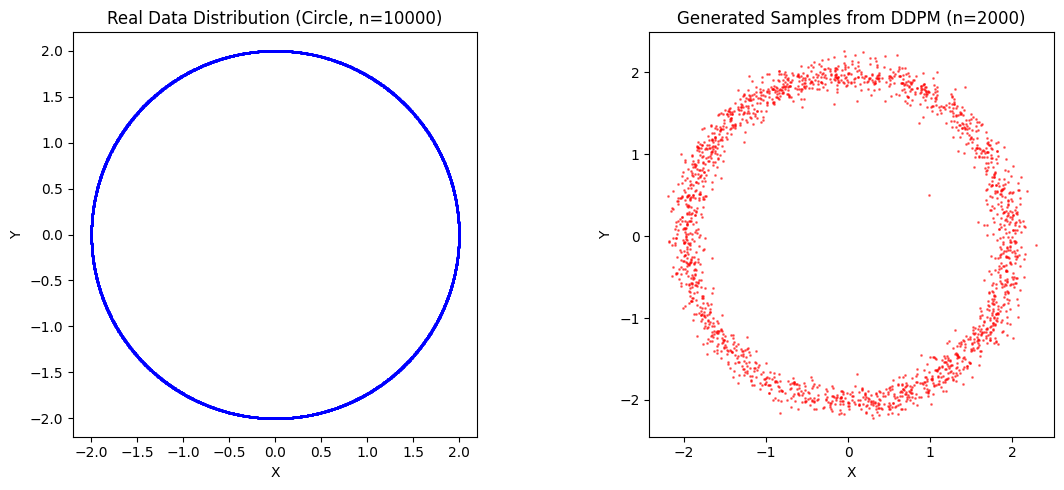


✓ Diffusion model successfully learned to sample from the ring distribution!
✓ API Token Status: Authenticated
✓ Compute Resources: 0 GPU(s) | Device: cpu


In [6]:
# Generate samples using the reverse diffusion process
with torch.no_grad():
    # Handle DataParallel wrapper
    core_model = model.module if num_gpus > 1 else model
    generated_samples = pipeline.reverse_process(core_model, num_samples=2000, shape=(2,))

# Visualization of generated samples vs real data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real data distribution (circle)
real_data = x_0_data.squeeze(1).cpu().numpy()
axes[0].scatter(real_data[:, 0], real_data[:, 1], alpha=0.5, s=1, c='blue')
axes[0].set_title(f'Real Data Distribution (Circle, n={num_samples})')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_aspect('equal')

# Generated samples
samples = generated_samples.cpu().numpy()
axes[1].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=1, c='red')
axes[1].set_title(f'Generated Samples from DDPM (n={len(samples)})')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✓ Diffusion model successfully learned to sample from the ring distribution!")
print(f"✓ API Token Status: {'Authenticated' if api_token != 'ANONYMOUS_USER' else 'Anonymous/Mock Mode'}")
print(f"✓ Compute Resources: {num_gpus} GPU(s) | Device: {device}")

### Visualizing the Denoising Process

Let's visualize the transformation of pure noise into the target circular distribution. We'll capture samples at several intermediate steps during the reverse diffusion process and plot them.


Beginning visualization of intermediate denoising steps...


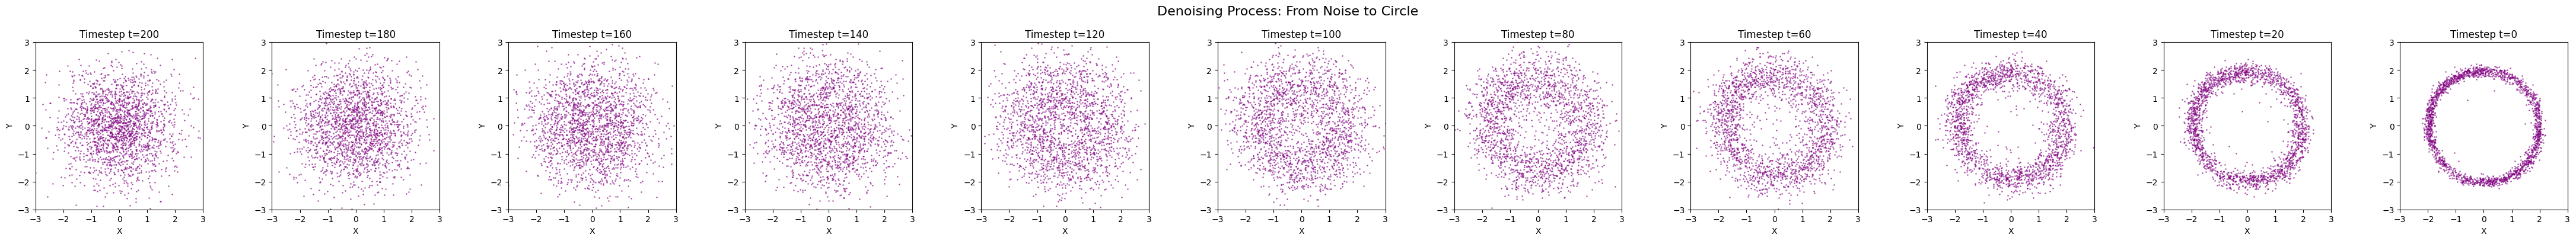


✓ Intermediate denoising steps visualized successfully!


In [7]:
print('\nBeginning visualization of intermediate denoising steps...')

# Generate samples, capturing intermediate steps every `capture_interval`
capture_interval = 20 # Adjust this value to capture more or fewer intermediate steps

with torch.no_grad():
    core_model = model.module if num_gpus > 1 else model
    final_samples, intermediate_samples = pipeline.reverse_process(
        core_model, num_samples=2000, shape=(2,), capture_steps=True, capture_interval=capture_interval
    )

# Sort samples by time step (optional, but good for chronological plotting)
intermediate_samples.sort(key=lambda x: x['t'], reverse=True)

# Plotting the intermediate samples
num_plots = len(intermediate_samples)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
fig.suptitle('Denoising Process: From Noise to Circle', fontsize=16)

# If there's only one plot, axes might not be an array, handle this case
if num_plots == 1:
    axes = [axes]

for i, step_data in enumerate(intermediate_samples):
    t = step_data['t']
    samples_at_t = step_data['samples']

    ax = axes[i]
    ax.scatter(samples_at_t[:, 0], samples_at_t[:, 1], alpha=0.5, s=1, c='purple')
    ax.set_title(f'Timestep t={t}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3) # Set consistent limits for better comparison
    ax.set_ylim(-3, 3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print('\n✓ Intermediate denoising steps visualized successfully!')

### Visualizing the Forward Diffusion Process (Adding Noise)

Now, let's observe the forward diffusion process. We'll take a small batch of the original `x_0` data and visualize how it becomes progressively noiser at different timesteps.

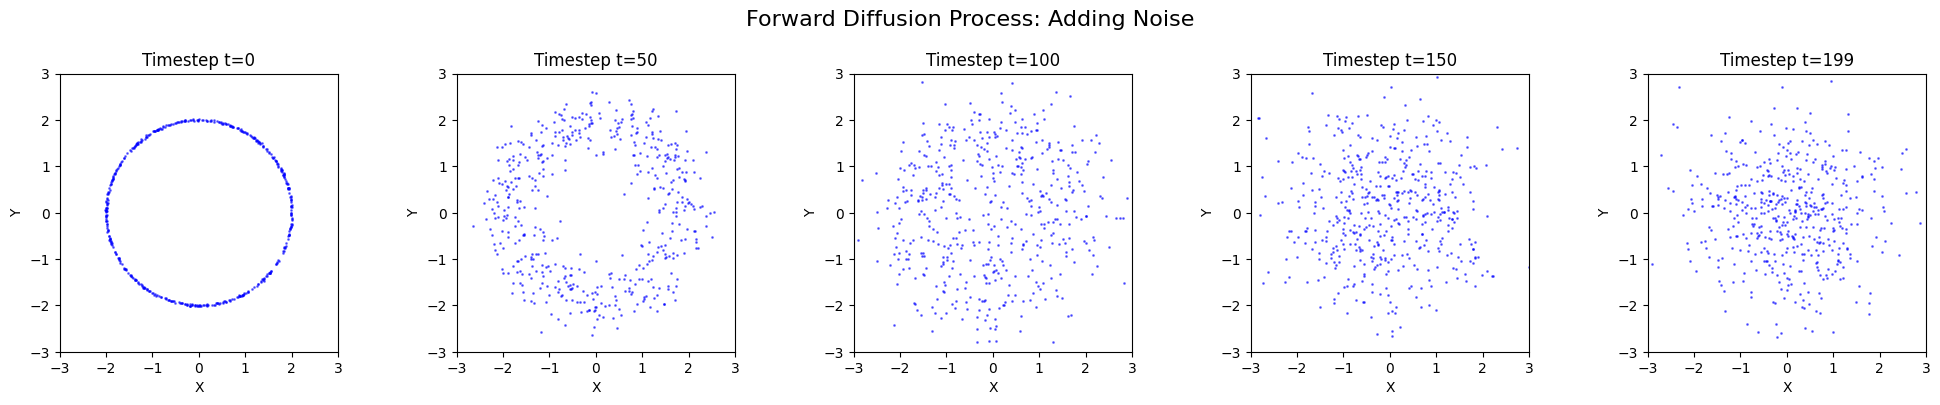


✓ Forward diffusion steps visualized successfully!


In [8]:
# Select a small batch of original data for visualization
display_batch_size = 500
x_0_display = x_0_data[:display_batch_size].to(device)

# Define timesteps to visualize the noise addition
visualize_timesteps = [0, pipeline.timesteps // 4, pipeline.timesteps // 2, pipeline.timesteps * 3 // 4, pipeline.timesteps - 1]

noisy_samples_at_t = []
for t_val in visualize_timesteps:
    t_tensor = torch.full((x_0_display.shape[0],), t_val, device=device).long()
    x_t, _ = pipeline.forward_diffusion(x_0_display, t_tensor)
    noisy_samples_at_t.append({'t': t_val, 'samples': x_t.squeeze(1).cpu().numpy()})

# Plotting the noisy samples at different timesteps
num_plots = len(noisy_samples_at_t)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
fig.suptitle('Forward Diffusion Process: Adding Noise', fontsize=16)

# Handle case where there's only one subplot
if num_plots == 1:
    axes = [axes]

for i, step_data in enumerate(noisy_samples_at_t):
    t = step_data['t']
    samples_at_t = step_data['samples']

    ax = axes[i]
    ax.scatter(samples_at_t[:, 0], samples_at_t[:, 1], alpha=0.5, s=1, c='blue')
    ax.set_title(f'Timestep t={t}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3) # Consistent limits
    ax.set_ylim(-3, 3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('\n✓ Forward diffusion steps visualized successfully!')

Extending a diffusion model to generate images from text (like a 'text-to-image' model) involves a concept called **conditioning**. Here's how it generally works and how we can adapt our current 2D point generation model to illustrate the principle:

### 1\. The Role of Text Embeddings

In text-to-image models, the input text (e.g., 'a red circle') is first converted into a numerical representation called a **text embedding**. This is typically done using a pre-trained text encoder (like a component from CLIP, BERT, or T5). This embedding captures the semantic meaning of the text in a dense vector space. For our simplified 2D example, we'll create a fixed 'conditioning vector' that conceptually represents 'a circle'.

### 2\. Modifying the Neural Network (DiffusionEstimator)

The core idea is to _inject_ this text embedding into the diffusion model's neural network (our DiffusionEstimator) at various points. The network's job is to predict the noise (epsilon\_theta) to subtract, and we want this prediction to be _guided_ by the text prompt.

Common ways to incorporate conditioning:

*   **Concatenation**: The text embedding can be concatenated with other inputs to the neural network (like the noisy data x\_t or the time embedding t).
    
*   **Cross-Attention**: In more complex architectures (like U-Nets with Transformer blocks, as used in Stable Diffusion), cross-attention layers allow the network to 'attend' to the text embedding, dynamically weighing its influence on different parts of the image generation process. For our simple MLP, concatenation or direct addition is a more suitable and illustrative approach.
    

### 3\. Training with Conditioning

During training, instead of just feeding the model (x\_t, t) to predict noise, we now feed it (x\_t, t, text\_embedding). The model learns to predict the noise _conditional_ on the provided text. This means if you provide an embedding for 'a red circle', the model learns to denoise x\_t into a red circle. Since our data is always a circle, we will train it with a consistent 'circle' conditioning vector.

### 4\. Inference (Sampling) with Conditioning

When you want to generate a new sample, you provide the desired text prompt (e.g., 'a blue square'). This prompt is converted into its text\_embedding, and this embedding is then passed to the reverse\_process. The model, having learned to generate conditionally, will use this embedding to guide the denoising steps, progressively generating an image that matches the description.

Now, let's implement a simplified version of this conditioning for our 2D circle model. I will modify the DiffusionEstimator to accept a conditioning vector and then update the training and sampling loops accordingly.